# Rank Percentile Score Distributions

Six-panel figure comparing **raw docking scores** (row 1) against **Guild-standardised scores** (row 2) across the three docking methods: **Vina**, **DiffDock**, and **Boltz**.

- Each method is assigned a consistent colour.
- All non-decoy compounds are shown in the method colour (categories pooled).
- Decoys are shown as a muted grey background KDE for reference.
- Source: `notebooks/analysis/data/figure_2_dockwizard_scores.txt`

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_FILE = "data/figure_2_guild_scores.txt"
OUT_DIR   = "np_synthetic_comparison/guild_figures"
os.makedirs(OUT_DIR, exist_ok=True)

# ── Proteins to exclude ──────────────────────────────────────────────────────
EXCLUDE_PROTEINS = {"7v6a", "8fx5", "8wrz", "8wu1", "8dzs"}

df = pd.read_csv(DATA_FILE, sep="\t")
df["pdb_id"] = df["protein_config_id"].str.split("-").str[0]
df = df[~df["pdb_id"].isin(EXCLUDE_PROTEINS)].copy()
print(f"Rows (after excluding {EXCLUDE_PROTEINS}): {len(df)}")
print(df["ligand_category"].value_counts())

Rows (after excluding {'8dzs', '7v6a', '8fx5', '8wu1', '8wrz'}): 120
ligand_category
decoy              100
Natural Product     10
weak-binder          5
strong-binder        5
Name: count, dtype: int64


In [2]:

# ── Palette & method specs ───────────────────────────────────────────────────
import matplotlib as mpl

mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 13,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 4.0,
    "ytick.major.size": 4.0,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "figure.dpi": 150,
})

METHOD_COLOR = {
    "Vina":     "#1f77b4",
    "DiffDock": "#ff7f0e",
    "Boltz-2":  "#2ca02c",
}
DECOY_COLOR = "#b0b0b0"

# New layout: 3 rows (one per method) × 2 columns (raw, rank percentile)
# (method_label, raw_col, raw_xlabel, rp_col, raw_filter)
METHOD_SPECS = [
    ("Vina",     "vina_score",     "Vina score (kcal/mol)",  "guild_vina_score",      lambda d, c: d[d[c] < 0.0]),
    ("DiffDock", "diffdock_score", "DiffDock confidence",    "guild_diffdock_score",  lambda d, c: d.dropna(subset=[c])),
    ("Boltz-2",  "boltz_score",    "Boltz-2 score",          "guild_boltz_score",     lambda d, c: d.dropna(subset=[c])),
]


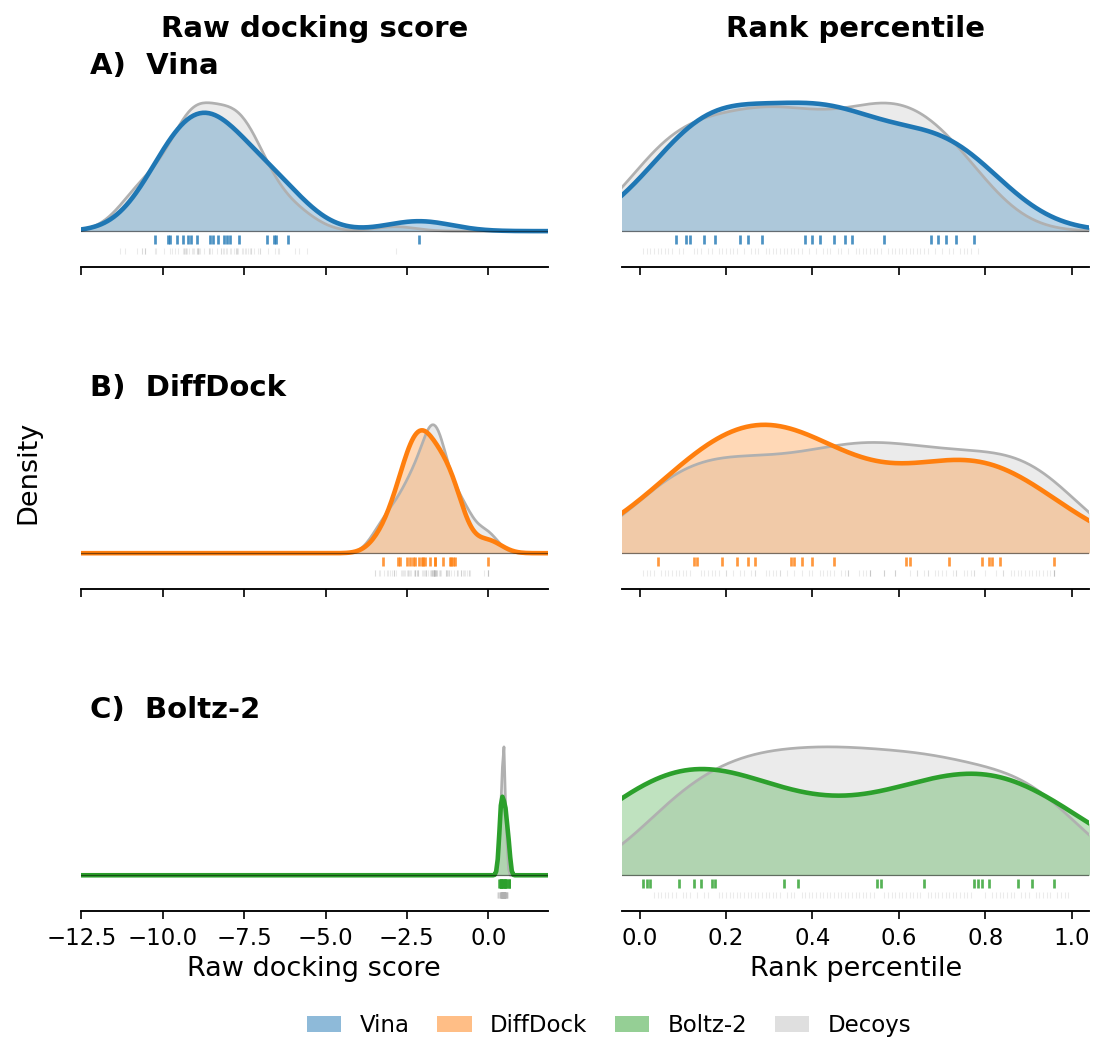

Saved figure_2_score_distributions in np_synthetic_comparison/guild_figures


In [3]:
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde


def kde_curve(values, x_grid):
    values = values.dropna()
    if len(values) < 2:
        return np.zeros_like(x_grid)
    return gaussian_kde(values, bw_method="scott")(x_grid)

N_GRID = 300
COL_TITLES = ["Raw docking score", "Rank percentile"]
PANEL_LABELS = ["A)", "B)", "C)"]   # one per row (method)

# ═══════════════════════════════════════════════════════════════════════════════
# PASS 0 — find global x-range for the LEFT column (raw scores)
# ═══════════════════════════════════════════════════════════════════════════════
global_xmin_left, global_xmax_left = np.inf, -np.inf

for row_idx, (method, raw_col, raw_xlabel, rp_col, raw_filter) in enumerate(METHOD_SPECS):
    sub = raw_filter(df, raw_col).dropna(subset=[raw_col, "ligand_category"]).copy()
    vals = sub[raw_col].dropna()
    if len(vals) > 0:
        global_xmin_left = min(global_xmin_left, vals.min())
        global_xmax_left = max(global_xmax_left, vals.max())

pad_left = (global_xmax_left - global_xmin_left) * 0.10
shared_xmin = global_xmin_left - pad_left
shared_xmax = global_xmax_left + pad_left
shared_x_grid = np.linspace(shared_xmin, shared_xmax, N_GRID)

# ═══════════════════════════════════════════════════════════════════════════════
# PASS 1 — precompute KDEs; track per-ROW max
# ═══════════════════════════════════════════════════════════════════════════════
precomp = {}
row_kde_max = [0.0, 0.0, 0.0]   # one per method-row

for row_idx, (method, raw_col, raw_xlabel, rp_col, raw_filter) in enumerate(METHOD_SPECS):
    panels = [
        (0, raw_col, raw_xlabel, raw_filter),
        (1, rp_col,  "Rank percentile", lambda d, c: d.dropna(subset=[c])),
    ]
    for col_idx, (ci, score_col, xlabel, filter_fn) in enumerate(panels):
        sub = filter_fn(df, score_col).dropna(subset=[score_col, "ligand_category"]).copy()
        decoy_vals     = sub.loc[sub["ligand_category"] == "decoy",  score_col].dropna()
        non_decoy_vals = sub.loc[sub["ligand_category"] != "decoy", score_col].dropna()
        all_vals = pd.concat([decoy_vals, non_decoy_vals]).dropna()

        if len(all_vals) < 2:
            precomp[(row_idx, ci)] = None
            continue

        # Left column: use the SHARED x grid
        # Right column: always span [0, 1] (rank percentile is bounded)
        if ci == 0:
            x_grid = shared_x_grid
        else:
            x_grid = np.linspace(-0.06, 1.06, N_GRID)

        kde_comp  = kde_curve(non_decoy_vals, x_grid)
        kde_decoy = kde_curve(decoy_vals, x_grid)

        row_kde_max[row_idx] = max(row_kde_max[row_idx], kde_comp.max(), kde_decoy.max())

        precomp[(row_idx, ci)] = {
            "x_grid": x_grid, "kde_comp": kde_comp, "kde_decoy": kde_decoy,
            "non_decoy_vals": non_decoy_vals, "decoy_vals": decoy_vals,
            "xlabel": xlabel, "method": method,
        }

# ═══════════════════════════════════════════════════════════════════════════════
# PASS 2 — draw 3×2 figure
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(
    3, 2,
    figsize=(8.0, 7.5),
    gridspec_kw={"hspace": 0.45, "wspace": 0.16},
)

# Shared x-limits: LEFT column = global raw range; RIGHT column = [0, 1]
for r in range(3):
    axes[r, 0].set_xlim(shared_xmin, shared_xmax)
    axes[r, 1].set_xlim(-0.04, 1.04)

for row_idx, (method, raw_col, raw_xlabel, rp_col, raw_filter) in enumerate(METHOD_SPECS):
    color = METHOD_COLOR[method]

    for col_idx in range(2):
        ax   = axes[row_idx, col_idx]
        data = precomp.get((row_idx, col_idx))
        if data is None:
            ax.set_visible(False)
            continue

        x_grid   = data["x_grid"]
        kde_comp = data["kde_comp"]
        kde_decoy= data["kde_decoy"]
        non_decoy_vals = data["non_decoy_vals"]
        decoy_vals     = data["decoy_vals"]

        # Per-panel KDE max so each panel showcases its own shape
        kmax = max(kde_comp.max(), kde_decoy.max())

        # KDEs — decoy background, then compounds on top
        ax.fill_between(x_grid, 0, kde_decoy, color=DECOY_COLOR, alpha=0.25, linewidth=0)
        ax.plot(x_grid, kde_decoy, color=DECOY_COLOR, linewidth=1.3)
        ax.fill_between(x_grid, 0, kde_comp,  color=color, alpha=0.30, linewidth=0)
        ax.plot(x_grid, kde_comp,  color=color, linewidth=2.2)

        # Separator
        ax.axhline(0, color="black", linewidth=0.6, alpha=0.5)

        # Rug ticks — compounds (upper band) and decoys (lower band)
        comp_y0  = -kmax * 0.03
        comp_y1  = comp_y0 - kmax * 0.07
        decoy_y0 = -kmax * 0.13
        decoy_y1 = decoy_y0 - kmax * 0.05

        for v in non_decoy_vals:
            ax.plot([v, v], [comp_y0, comp_y1],
                    color=color, linewidth=1.3, alpha=0.80, solid_capstyle="butt")
        for v in decoy_vals.sample(min(500, len(decoy_vals)), random_state=42):
            ax.plot([v, v], [decoy_y0, decoy_y1],
                    color=DECOY_COLOR, linewidth=0.5, alpha=0.25, solid_capstyle="butt")

        # Y-limits: add headroom so the panel label never overlaps curves
        ax.set_ylim(-kmax * 0.28, kmax * 1.45)

        # Panel label only on left column (A, B, C + method name)
        if col_idx == 0:
            ax.text(0.02, 0.97, f"{PANEL_LABELS[row_idx]}  {method}",
                    transform=ax.transAxes, fontsize=14, fontweight="bold",
                    va="top", ha="left")

        # Axes cosmetics
        ax.tick_params(axis="y", left=False, labelleft=False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)

        # x-labels: only on bottom row for BOTH columns (shared x within each column)
        if row_idx == 2:
            if col_idx == 0:
                ax.set_xlabel("Raw docking score", labelpad=3)
            else:
                ax.set_xlabel("Rank percentile", labelpad=3)
        else:
            ax.tick_params(axis="x", labelbottom=False)
            ax.set_xlabel("")

        # Column titles on first row only
        if row_idx == 0:
            ax.set_title(COL_TITLES[col_idx], pad=4)

# Shared y-label
fig.text(0.005, 0.5, "Density", va="center", ha="left",
         rotation="vertical", fontsize=13)
fig.subplots_adjust(left=0.06)

# Shared legend
legend_handles = [
    Patch(facecolor=METHOD_COLOR[m], alpha=0.5, label=m)
    for m in ["Vina", "DiffDock", "Boltz-2"]
] + [
    Patch(facecolor=DECOY_COLOR, alpha=0.4, label="Decoys"),
]
fig.legend(
    handles=legend_handles,
    loc="lower center", ncol=4, frameon=False,
    bbox_to_anchor=(0.5, -0.02),
    columnspacing=1.2, handlelength=1.5,
)

# Save
for ext in ("png", "pdf", "svg"):
    out = os.path.join(OUT_DIR, f"figure_2_score_distributions.{ext}")
    fig.savefig(out, dpi=600, bbox_inches="tight")

plt.show()
print(f"Saved figure_2_score_distributions in {OUT_DIR}")


## Guild rank alluvial plot

Three columns — one per docking method — compounds stacked by Guild rank (rank 1 = best score = top).  
Lines connect the same compound across adjacent method layers, with colour transitioning from the left method to the right method colour.  
Decoys are drawn thinner and more transparent to keep binders and NPs visually prominent.

Non-decoy compounds: 20
ligand_category
Natural Product    10
weak-binder         5
strong-binder       5
Name: count, dtype: int64


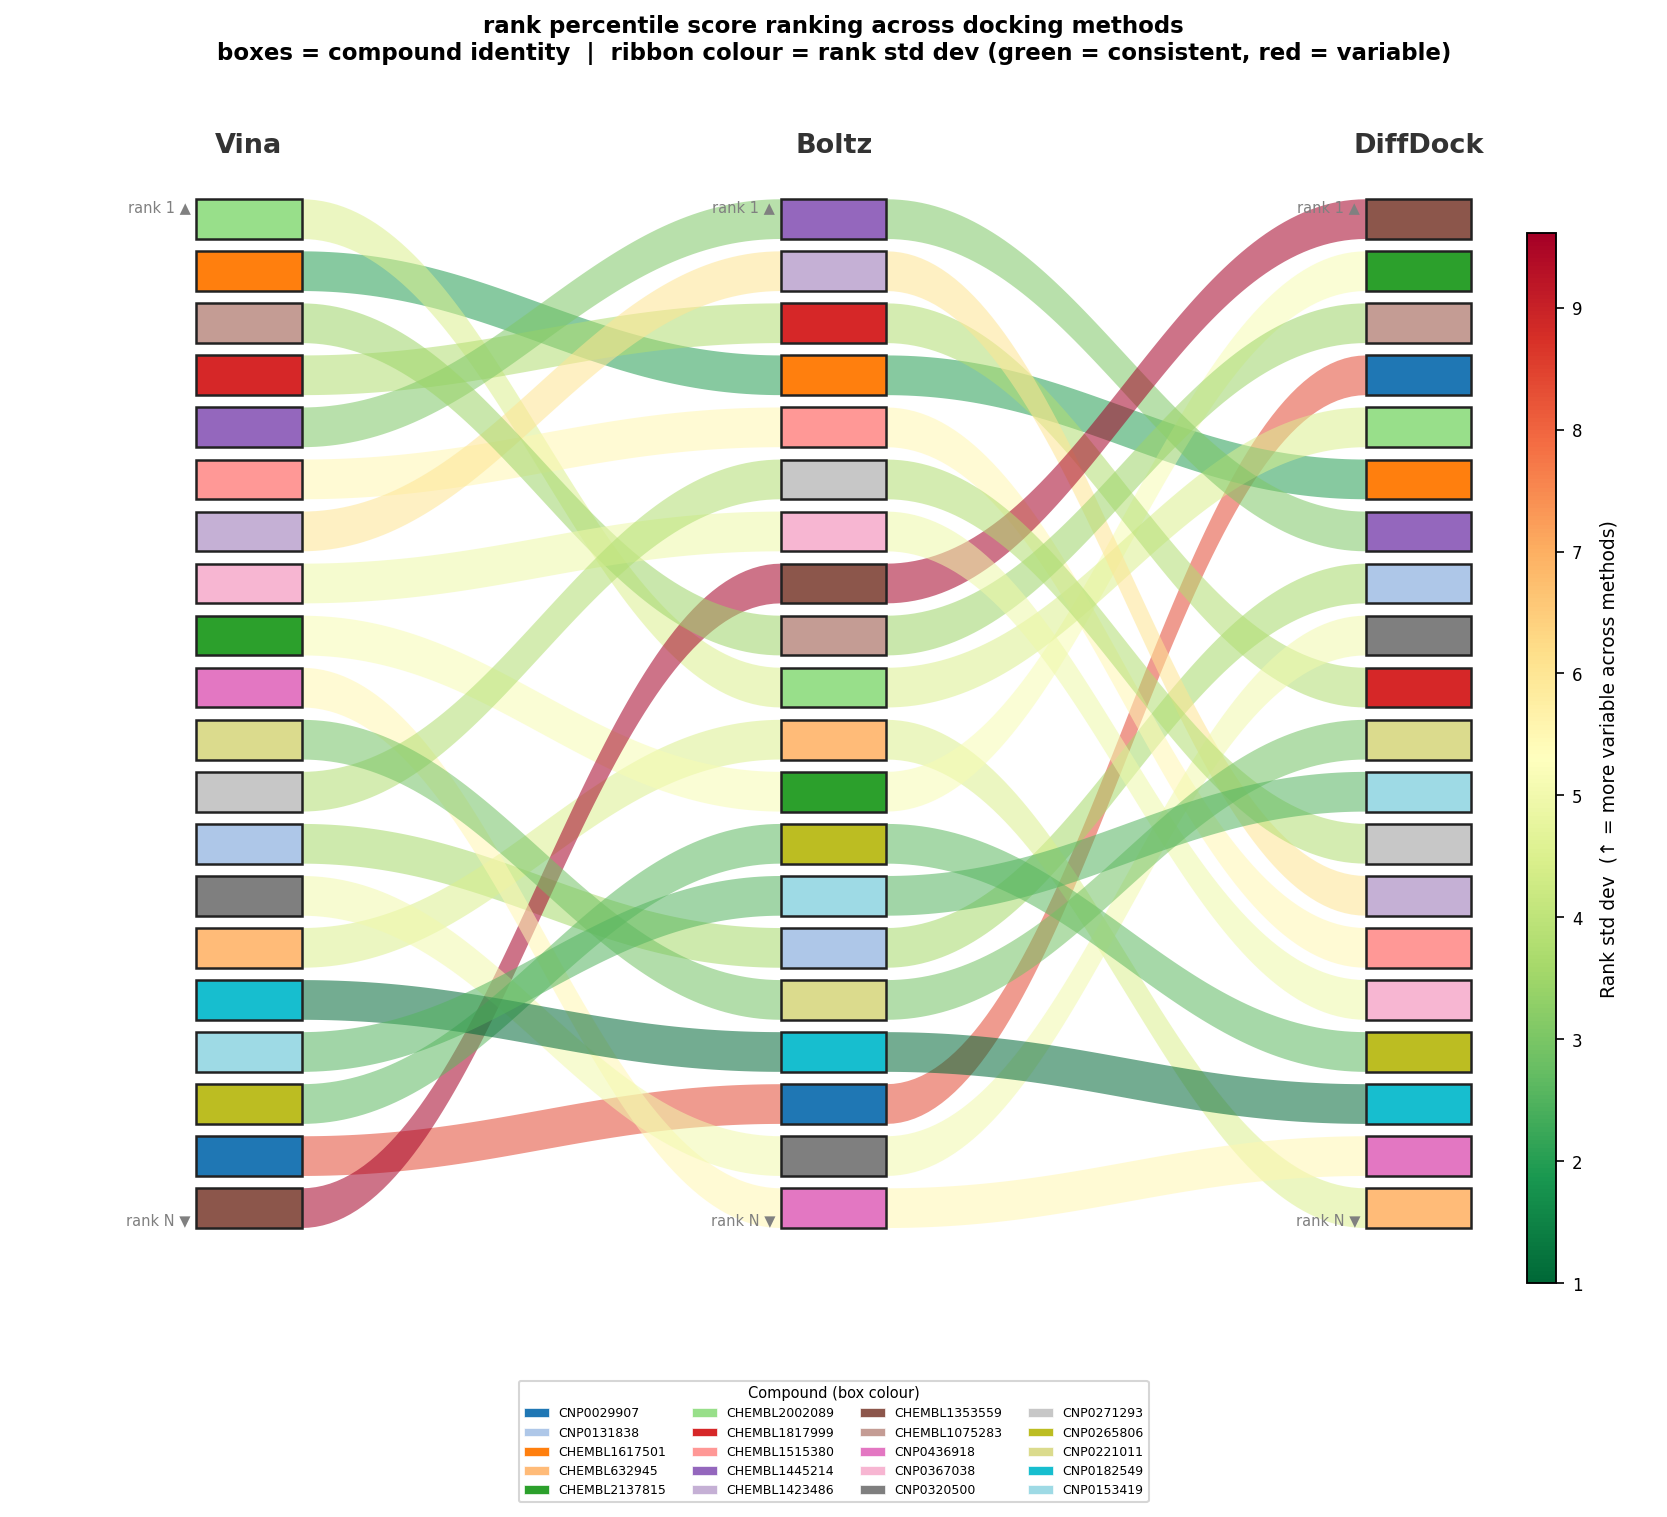

Saved: np_synthetic_comparison/guild_figures/guild_rank_alluvial.png


In [4]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# ── Setup ─────────────────────────────────────────────────────────────────────
GUILD_COLS = [
    ("Vina",     "guild_vina_score"),
    ("Boltz",    "guild_boltz_score"),
    ("DiffDock", "guild_diffdock_score"),
]
N_METHODS   = len(GUILD_COLS)
X_POSITIONS = np.array([0.0, 1.0, 2.0])
BOX_WIDTH   = 0.18
BOX_GAP     = 0.012

# ── Filter: non-decoys only ───────────────────────────────────────────────────
non_decoy = df[df["ligand_category"] != "decoy"].copy()
rp_score_cols = [c for _, c in GUILD_COLS]
non_decoy = non_decoy.dropna(subset=rp_score_cols, how="all").reset_index(drop=True)
n_compounds = len(non_decoy)
print(f"Non-decoy compounds: {n_compounds}")
print(non_decoy["ligand_category"].value_counts())

# ── One unique colour per compound (boxes) ───────────────────────────────────
cmap = plt.colormaps["tab20"].resampled(max(n_compounds, 20))
if n_compounds > 20:
    cmap = plt.colormaps["hsv"].resampled(n_compounds)
compound_colors = {
    row["ligand_id"]: mcolors.to_hex(cmap(i / n_compounds))
    for i, (_, row) in enumerate(non_decoy.iterrows())
}

# ── Rank std per compound (ribbon colour) ─────────────────────────────────────
# Measures how consistently a compound is ranked across the three methods.
# Low std = stable rank; high std = rank jumps wildly between methods.
rank_cols = []
for method, col in GUILD_COLS:
    non_decoy[f"rank_{method}"] = non_decoy[col].rank(method="first", ascending=True)
    rank_cols.append(f"rank_{method}")

non_decoy["rank_std"] = non_decoy[rank_cols].std(axis=1)
rank_std_max = non_decoy["rank_std"].max()
rank_std_min = non_decoy["rank_std"].min()

# RdYlGn_r: green = consistent, red = variable
ribbon_cmap = plt.colormaps["RdYlGn_r"]
def ribbon_color(lig_id):
    std = non_decoy.loc[non_decoy["ligand_id"] == lig_id, "rank_std"].values[0]
    t   = (std - rank_std_min) / (rank_std_max - rank_std_min + 1e-9)
    return ribbon_cmap(t)

# ── Per-layer sorted positions ────────────────────────────────────────────────
def layer_positions(col, total_height=1.0):
    sub   = non_decoy[["ligand_id", col]].dropna(subset=[col]).copy()
    sub   = sub.sort_values(col, ascending=True).reset_index(drop=True)
    n     = len(sub)
    box_h = (total_height - BOX_GAP * (n - 1)) / n
    positions = {}
    for rank, row in sub.iterrows():
        y_top    = total_height - rank * (box_h + BOX_GAP)
        y_centre = y_top - box_h / 2
        positions[row["ligand_id"]] = {"y_centre": y_centre, "box_h": box_h}
    return positions

TOTAL_H   = 1.0
layer_pos = {method: layer_positions(col) for method, col in GUILD_COLS}

# ── Bezier ribbon ─────────────────────────────────────────────────────────────
def ribbon(ax, x0, y0, x1, y1, h0, h1, color, alpha=0.4, n=80):
    t   = np.linspace(0, 1, n)
    cx0 = x0 + BOX_WIDTH / 2 + (x1 - x0 - BOX_WIDTH) * 0.4
    cx1 = x1 - BOX_WIDTH / 2 - (x1 - x0 - BOX_WIDTH) * 0.4

    top_by = (1-t)**3*(y0+h0/2) + 3*(1-t)**2*t*(y0+h0/2) + 3*(1-t)*t**2*(y1+h1/2) + t**3*(y1+h1/2)
    top_bx = (1-t)**3*(x0+BOX_WIDTH/2) + 3*(1-t)**2*t*cx0 + 3*(1-t)*t**2*cx1 + t**3*(x1-BOX_WIDTH/2)
    bot_by = (1-t)**3*(y0-h0/2) + 3*(1-t)**2*t*(y0-h0/2) + 3*(1-t)*t**2*(y1-h1/2) + t**3*(y1-h1/2)

    poly_x = np.concatenate([top_bx, top_bx[::-1]])
    poly_y = np.concatenate([top_by, bot_by[::-1]])
    ax.fill(poly_x, poly_y, color=color, alpha=alpha, linewidth=0)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 10), constrained_layout=True)

# Ribbons first (behind boxes) — coloured by rank std (green=consistent, red=variable)
for i in range(N_METHODS - 1):
    m_left,  _ = GUILD_COLS[i]
    m_right, _ = GUILD_COLS[i + 1]
    pos_left   = layer_pos[m_left]
    pos_right  = layer_pos[m_right]
    for lig_id in compound_colors:
        if lig_id not in pos_left or lig_id not in pos_right:
            continue
        p0 = pos_left[lig_id]
        p1 = pos_right[lig_id]
        ribbon(ax, X_POSITIONS[i], p0["y_centre"], X_POSITIONS[i+1], p1["y_centre"],
               p0["box_h"], p1["box_h"], color=ribbon_color(lig_id), alpha=0.55)

# Compound boxes on top
for col_idx, (method, col) in enumerate(GUILD_COLS):
    x = X_POSITIONS[col_idx]
    for lig_id, pinfo in layer_pos[method].items():
        color = compound_colors[lig_id]
        y_low = pinfo["y_centre"] - pinfo["box_h"] / 2
        rect  = mpatches.FancyBboxPatch(
            (x - BOX_WIDTH / 2, y_low), BOX_WIDTH, pinfo["box_h"],
            boxstyle="square,pad=0",
            facecolor=color, edgecolor="#222222", linewidth=1.2, zorder=3,
        )
        ax.add_patch(rect)

# ── Method labels (neutral dark colour) ──────────────────────────────────────
for xi, (method, _) in zip(X_POSITIONS, GUILD_COLS, strict=False):
    ax.text(xi, TOTAL_H + 0.04, method,
            ha="center", va="bottom", fontsize=13, fontweight="bold",
            color="#333333")
    ax.text(xi - BOX_WIDTH / 2 - 0.01, TOTAL_H,  "rank 1 ▲",
            ha="right", va="top",    fontsize=7, color="gray")
    ax.text(xi - BOX_WIDTH / 2 - 0.01, 0.0,       "rank N ▼",
            ha="right", va="bottom", fontsize=7, color="gray")

ax.set_xlim(-0.4, N_METHODS - 1 + 0.4)
ax.set_ylim(-0.06, TOTAL_H + 0.12)
ax.axis("off")

# ── Colorbar for rank std ─────────────────────────────────────────────────────
import matplotlib.cm as cm
from matplotlib.colors import Normalize

norm    = Normalize(vmin=rank_std_min, vmax=rank_std_max)
sm      = cm.ScalarMappable(cmap=ribbon_cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.92, 0.15, 0.018, 0.70])
cbar    = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Rank std dev  (↑ = more variable across methods)", fontsize=9, labelpad=8)
cbar.ax.tick_params(labelsize=8)

# ── Compound legend ───────────────────────────────────────────────────────────
handles = [
    mpatches.Patch(facecolor=compound_colors[row["ligand_id"]],
                   edgecolor="white", linewidth=0.3,
                   label=row["ligand_id"])
    for _, row in non_decoy.iterrows()
]
ax.legend(
    handles=handles, title="Compound (box colour)", fontsize=6, title_fontsize=7,
    loc="lower center", ncol=4, frameon=True,
    bbox_to_anchor=(0.5, -0.18),
)

ax.set_title(
    "rank percentile score ranking across docking methods\n"
    "boxes = compound identity  |  ribbon colour = rank std dev (green = consistent, red = variable)",
    fontsize=11, fontweight="bold", pad=8,
)

out = os.path.join(OUT_DIR, "guild_rank_alluvial.png")
fig.savefig(out, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

## Guild rank alluvial — v1 (compound-coloured ribbons)

Same layout as above but ribbons carry the **compound colour** rather than the rank-std encoding,
so you can follow each compound visually across methods without the variability signal.
Saved as `guild_rank_alluvial_v1.png`.


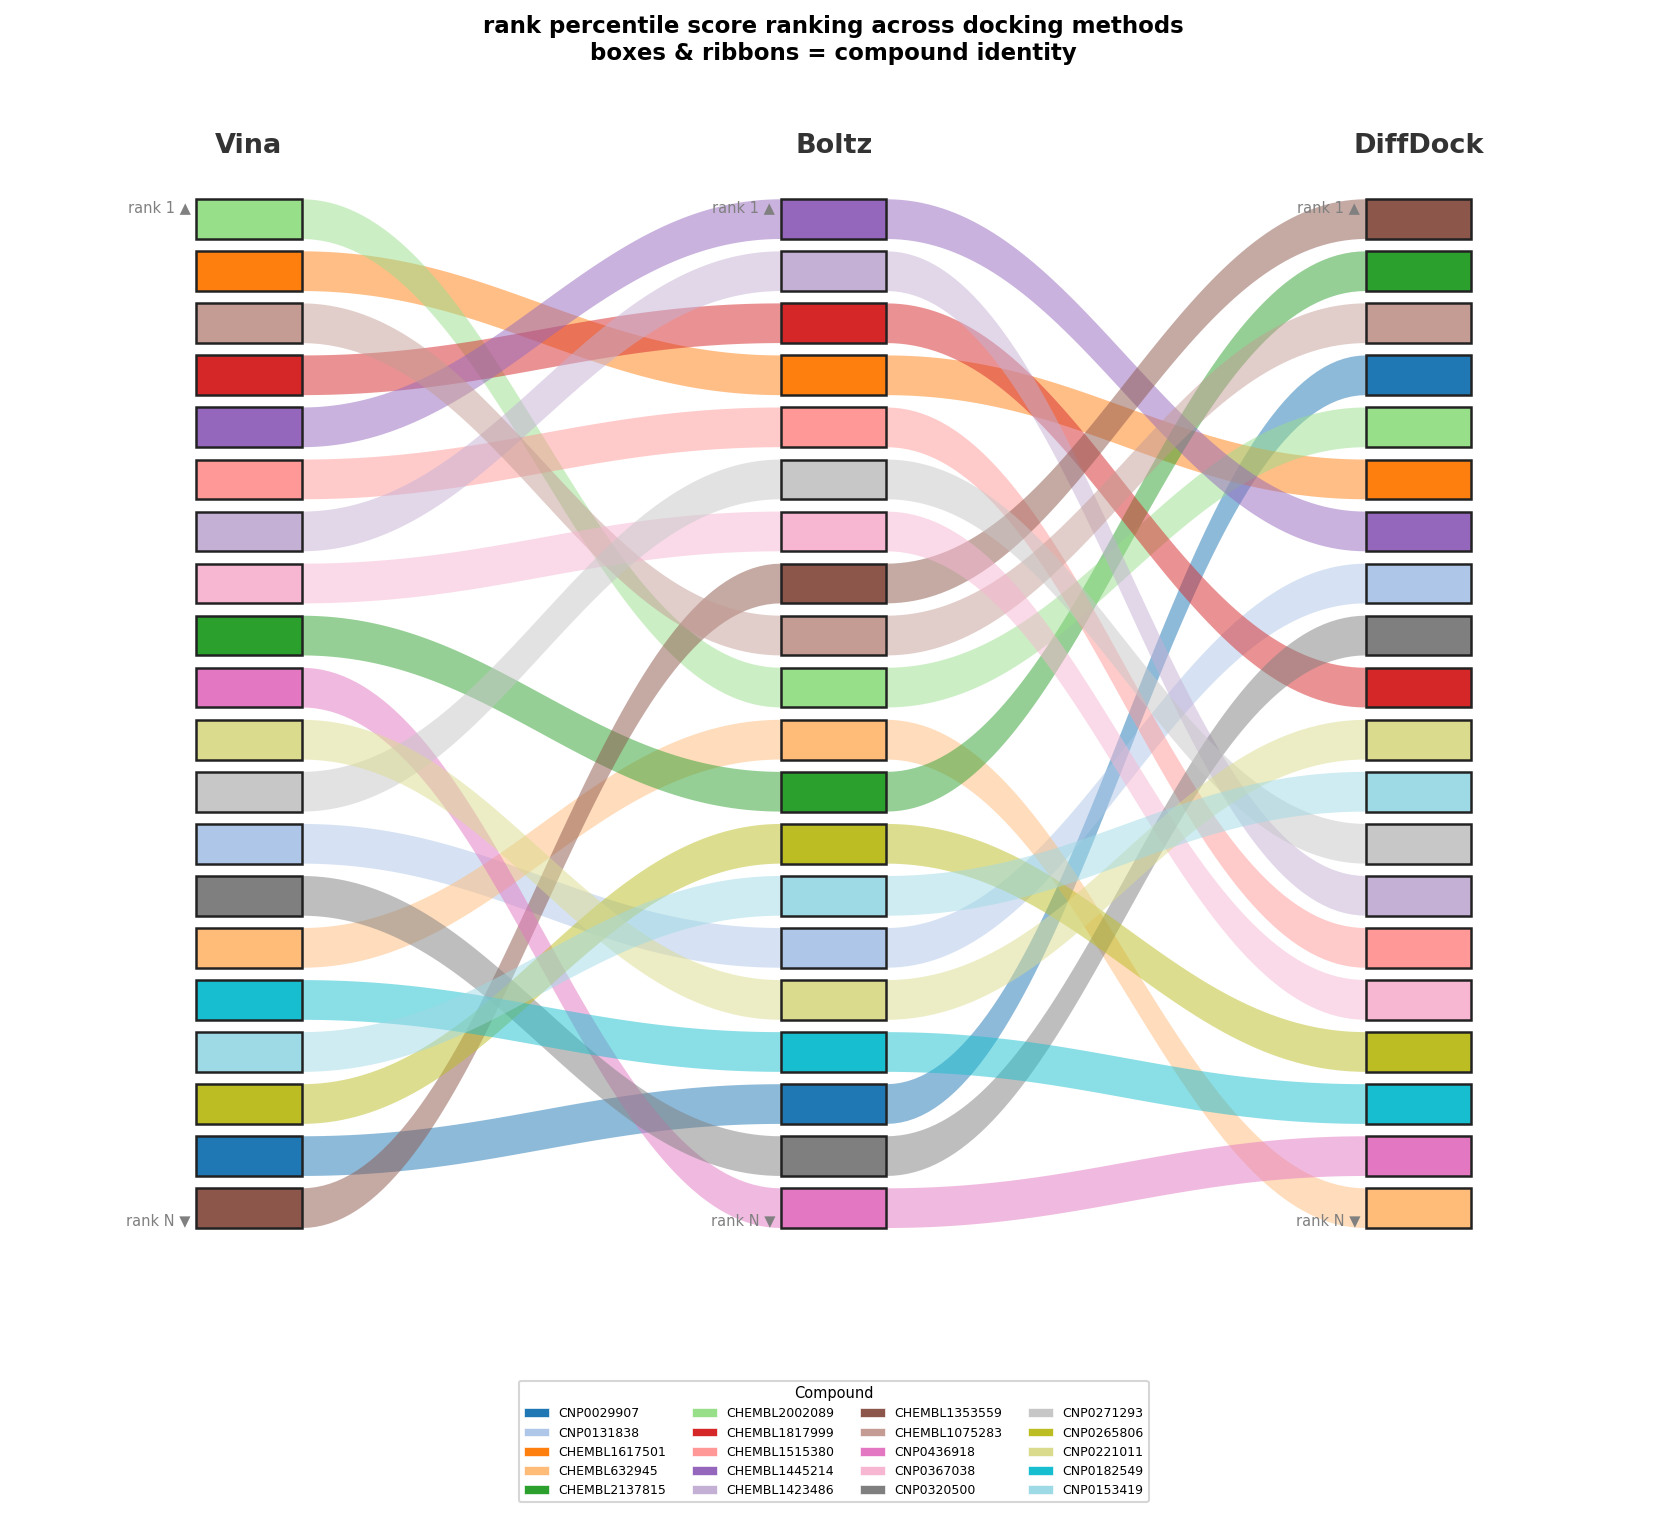

Saved: np_synthetic_comparison/guild_figures/guild_rank_alluvial_v1.png


In [5]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# ── Reuse configuration from the rank-std cell ────────────────────────────────
# GUILD_COLS, X_POSITIONS, BOX_WIDTH, BOX_GAP, TOTAL_H, n_compounds,
# compound_colors, layer_pos, ribbon() are all still in scope.

def ribbon_v1(ax, x0, y0, x1, y1, h0, h1, color, alpha=0.4, n=80):
    """Bezier ribbon with a uniform compound colour."""
    t   = np.linspace(0, 1, n)
    cx0 = x0 + BOX_WIDTH / 2 + (x1 - x0 - BOX_WIDTH) * 0.4
    cx1 = x1 - BOX_WIDTH / 2 - (x1 - x0 - BOX_WIDTH) * 0.4

    top_by = (1-t)**3*(y0+h0/2) + 3*(1-t)**2*t*(y0+h0/2) + 3*(1-t)*t**2*(y1+h1/2) + t**3*(y1+h1/2)
    top_bx = (1-t)**3*(x0+BOX_WIDTH/2) + 3*(1-t)**2*t*cx0 + 3*(1-t)*t**2*cx1 + t**3*(x1-BOX_WIDTH/2)
    bot_by = (1-t)**3*(y0-h0/2) + 3*(1-t)**2*t*(y0-h0/2) + 3*(1-t)*t**2*(y1-h1/2) + t**3*(y1-h1/2)

    poly_x = np.concatenate([top_bx, top_bx[::-1]])
    poly_y = np.concatenate([top_by, bot_by[::-1]])
    ax.fill(poly_x, poly_y, color=color, alpha=alpha, linewidth=0)

# ── Figure ────────────────────────────────────────────────────────────────────
fig_v1, ax_v1 = plt.subplots(figsize=(11, 10), constrained_layout=True)

# Ribbons first — coloured by compound identity
for i in range(N_METHODS - 1):
    m_left,  _ = GUILD_COLS[i]
    m_right, _ = GUILD_COLS[i + 1]
    pos_left   = layer_pos[m_left]
    pos_right  = layer_pos[m_right]
    for lig_id in compound_colors:
        if lig_id not in pos_left or lig_id not in pos_right:
            continue
        p0 = pos_left[lig_id]
        p1 = pos_right[lig_id]
        ribbon_v1(ax_v1, X_POSITIONS[i], p0["y_centre"], X_POSITIONS[i+1], p1["y_centre"],
                  p0["box_h"], p1["box_h"], color=compound_colors[lig_id], alpha=0.50)

# Compound boxes on top
for col_idx, (method, col) in enumerate(GUILD_COLS):
    x = X_POSITIONS[col_idx]
    for lig_id, pinfo in layer_pos[method].items():
        color = compound_colors[lig_id]
        y_low = pinfo["y_centre"] - pinfo["box_h"] / 2
        rect  = mpatches.FancyBboxPatch(
            (x - BOX_WIDTH / 2, y_low), BOX_WIDTH, pinfo["box_h"],
            boxstyle="square,pad=0",
            facecolor=color, edgecolor="#222222", linewidth=1.2, zorder=3,
        )
        ax_v1.add_patch(rect)

# Method labels
for xi, (method, _) in zip(X_POSITIONS, GUILD_COLS, strict=False):
    ax_v1.text(xi, TOTAL_H + 0.04, method,
               ha="center", va="bottom", fontsize=13, fontweight="bold",
               color="#333333")
    ax_v1.text(xi - BOX_WIDTH / 2 - 0.01, TOTAL_H,  "rank 1 ▲",
               ha="right", va="top",    fontsize=7, color="gray")
    ax_v1.text(xi - BOX_WIDTH / 2 - 0.01, 0.0,       "rank N ▼",
               ha="right", va="bottom", fontsize=7, color="gray")

ax_v1.set_xlim(-0.4, N_METHODS - 1 + 0.4)
ax_v1.set_ylim(-0.06, TOTAL_H + 0.12)
ax_v1.axis("off")

# ── Compound legend ───────────────────────────────────────────────────────────
handles_v1 = [
    mpatches.Patch(facecolor=compound_colors[row["ligand_id"]],
                   edgecolor="white", linewidth=0.3,
                   label=row["ligand_id"])
    for _, row in non_decoy.iterrows()
]
ax_v1.legend(
    handles=handles_v1, title="Compound", fontsize=6, title_fontsize=7,
    loc="lower center", ncol=4, frameon=True,
    bbox_to_anchor=(0.5, -0.18),
)

ax_v1.set_title(
    "rank percentile score ranking across docking methods\n"
    "boxes & ribbons = compound identity",
    fontsize=11, fontweight="bold", pad=8,
)

out_v1 = os.path.join(OUT_DIR, "guild_rank_alluvial_v1.png")
fig_v1.savefig(out_v1, dpi=600, bbox_inches="tight")
plt.show()
print(f"Saved: {out_v1}")


## Composite panel figures

Two multi-panel figures combining the score-distribution plot with each Sankey variant.
- **Panel A** — distributions + Sankey v1 (compound-coloured ribbons) → `guild_panel_v1.png`
- **Panel B** — distributions + Sankey v2 (rank-std ribbon colour) → `guild_panel_v2.png`


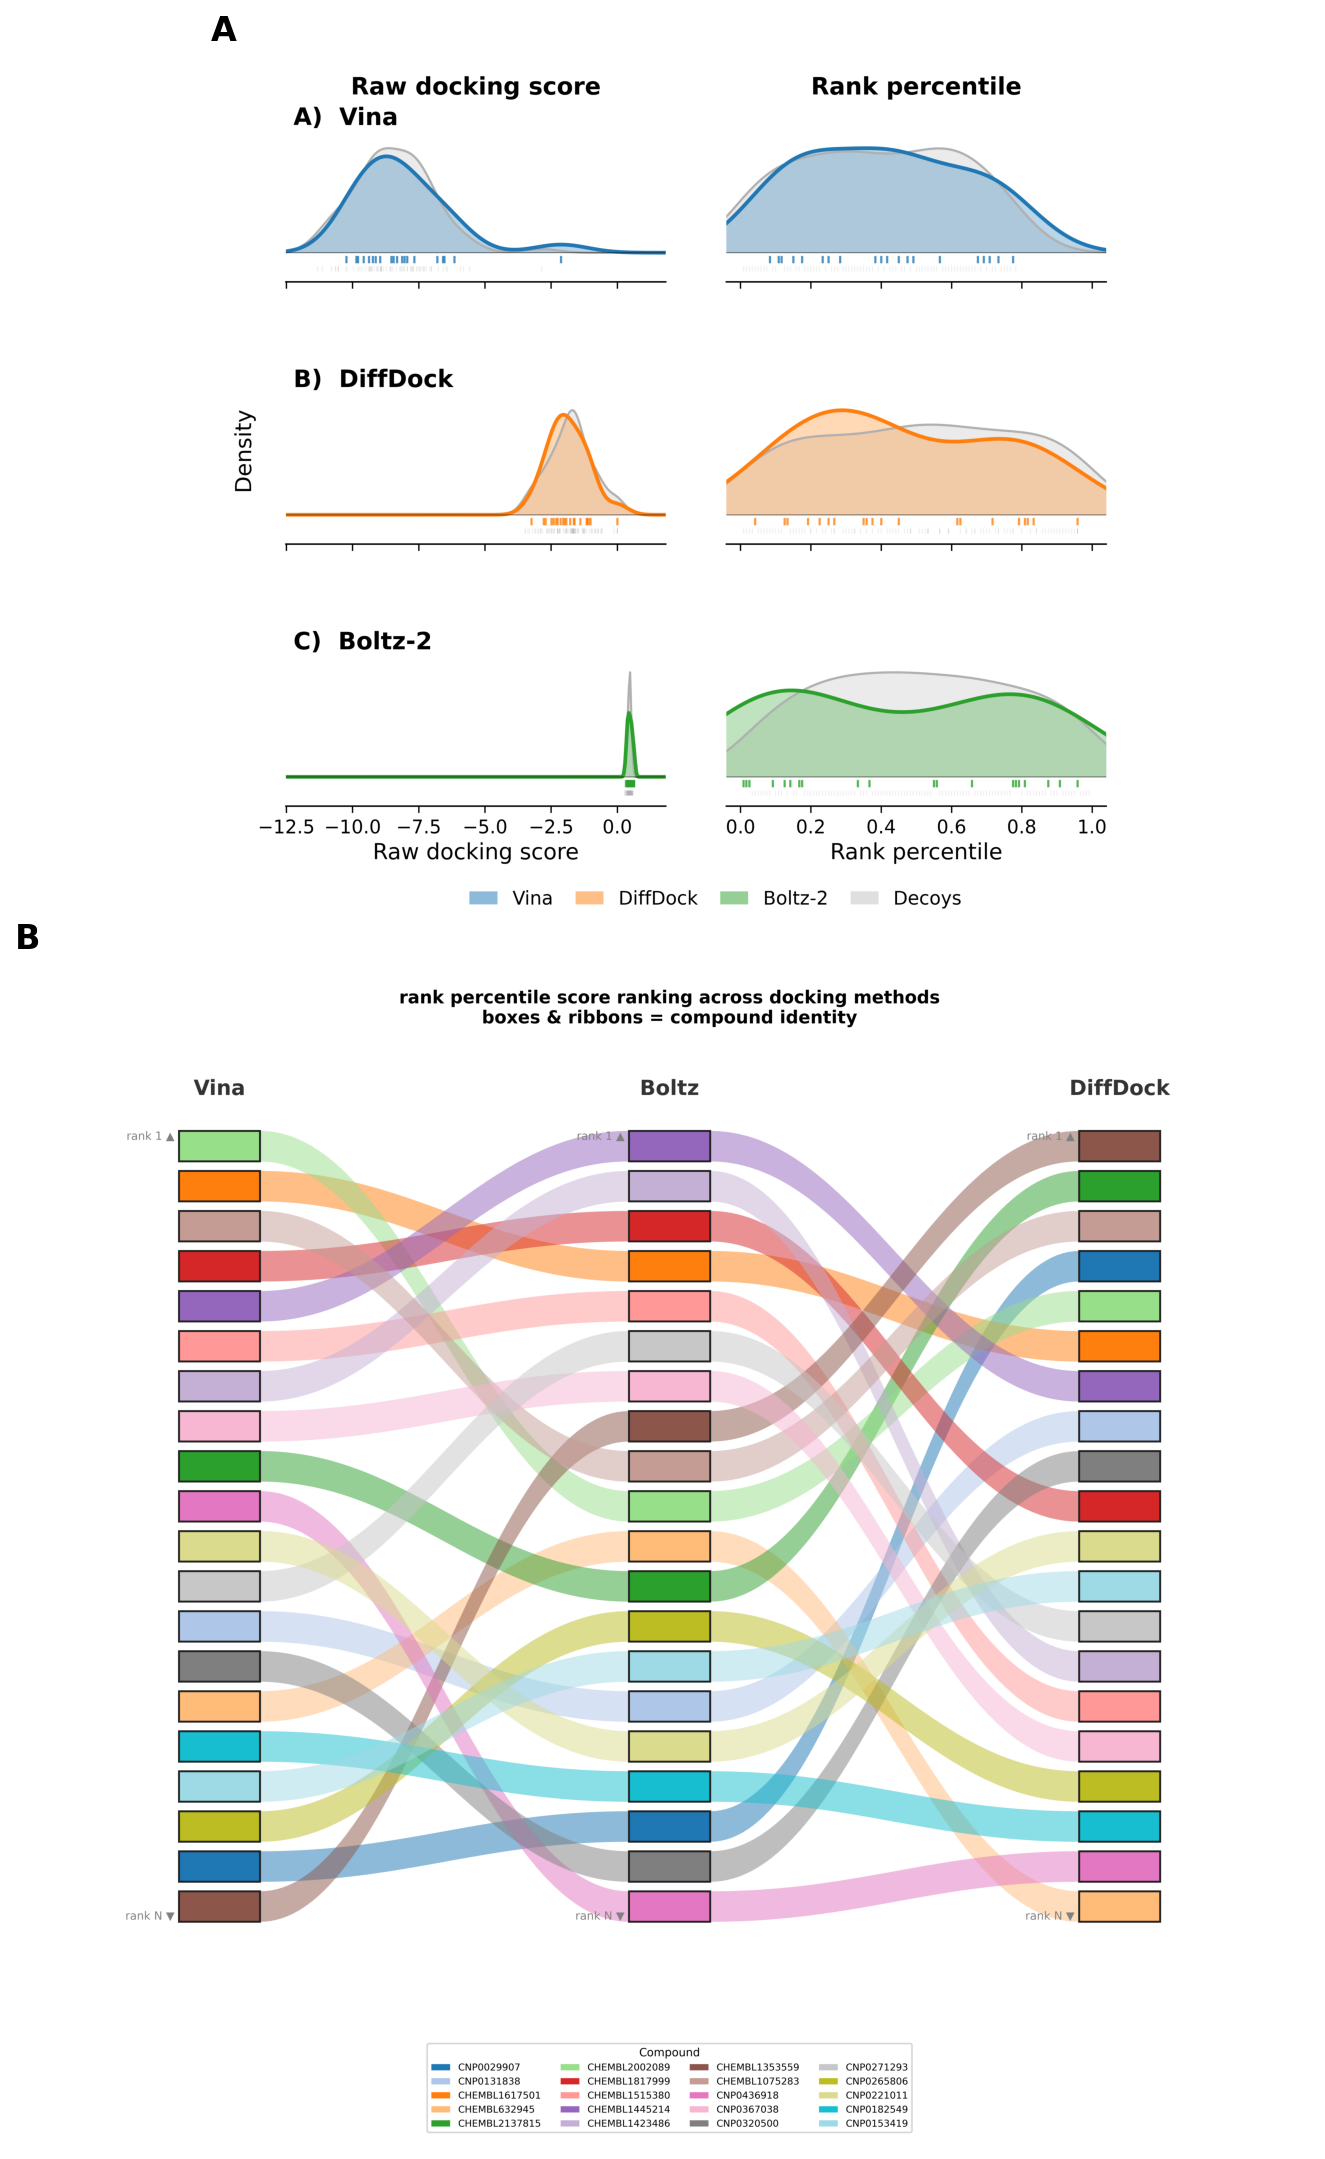

Saved panel v1 (compound ribbons): np_synthetic_comparison/guild_figures/guild_panel_v1.png


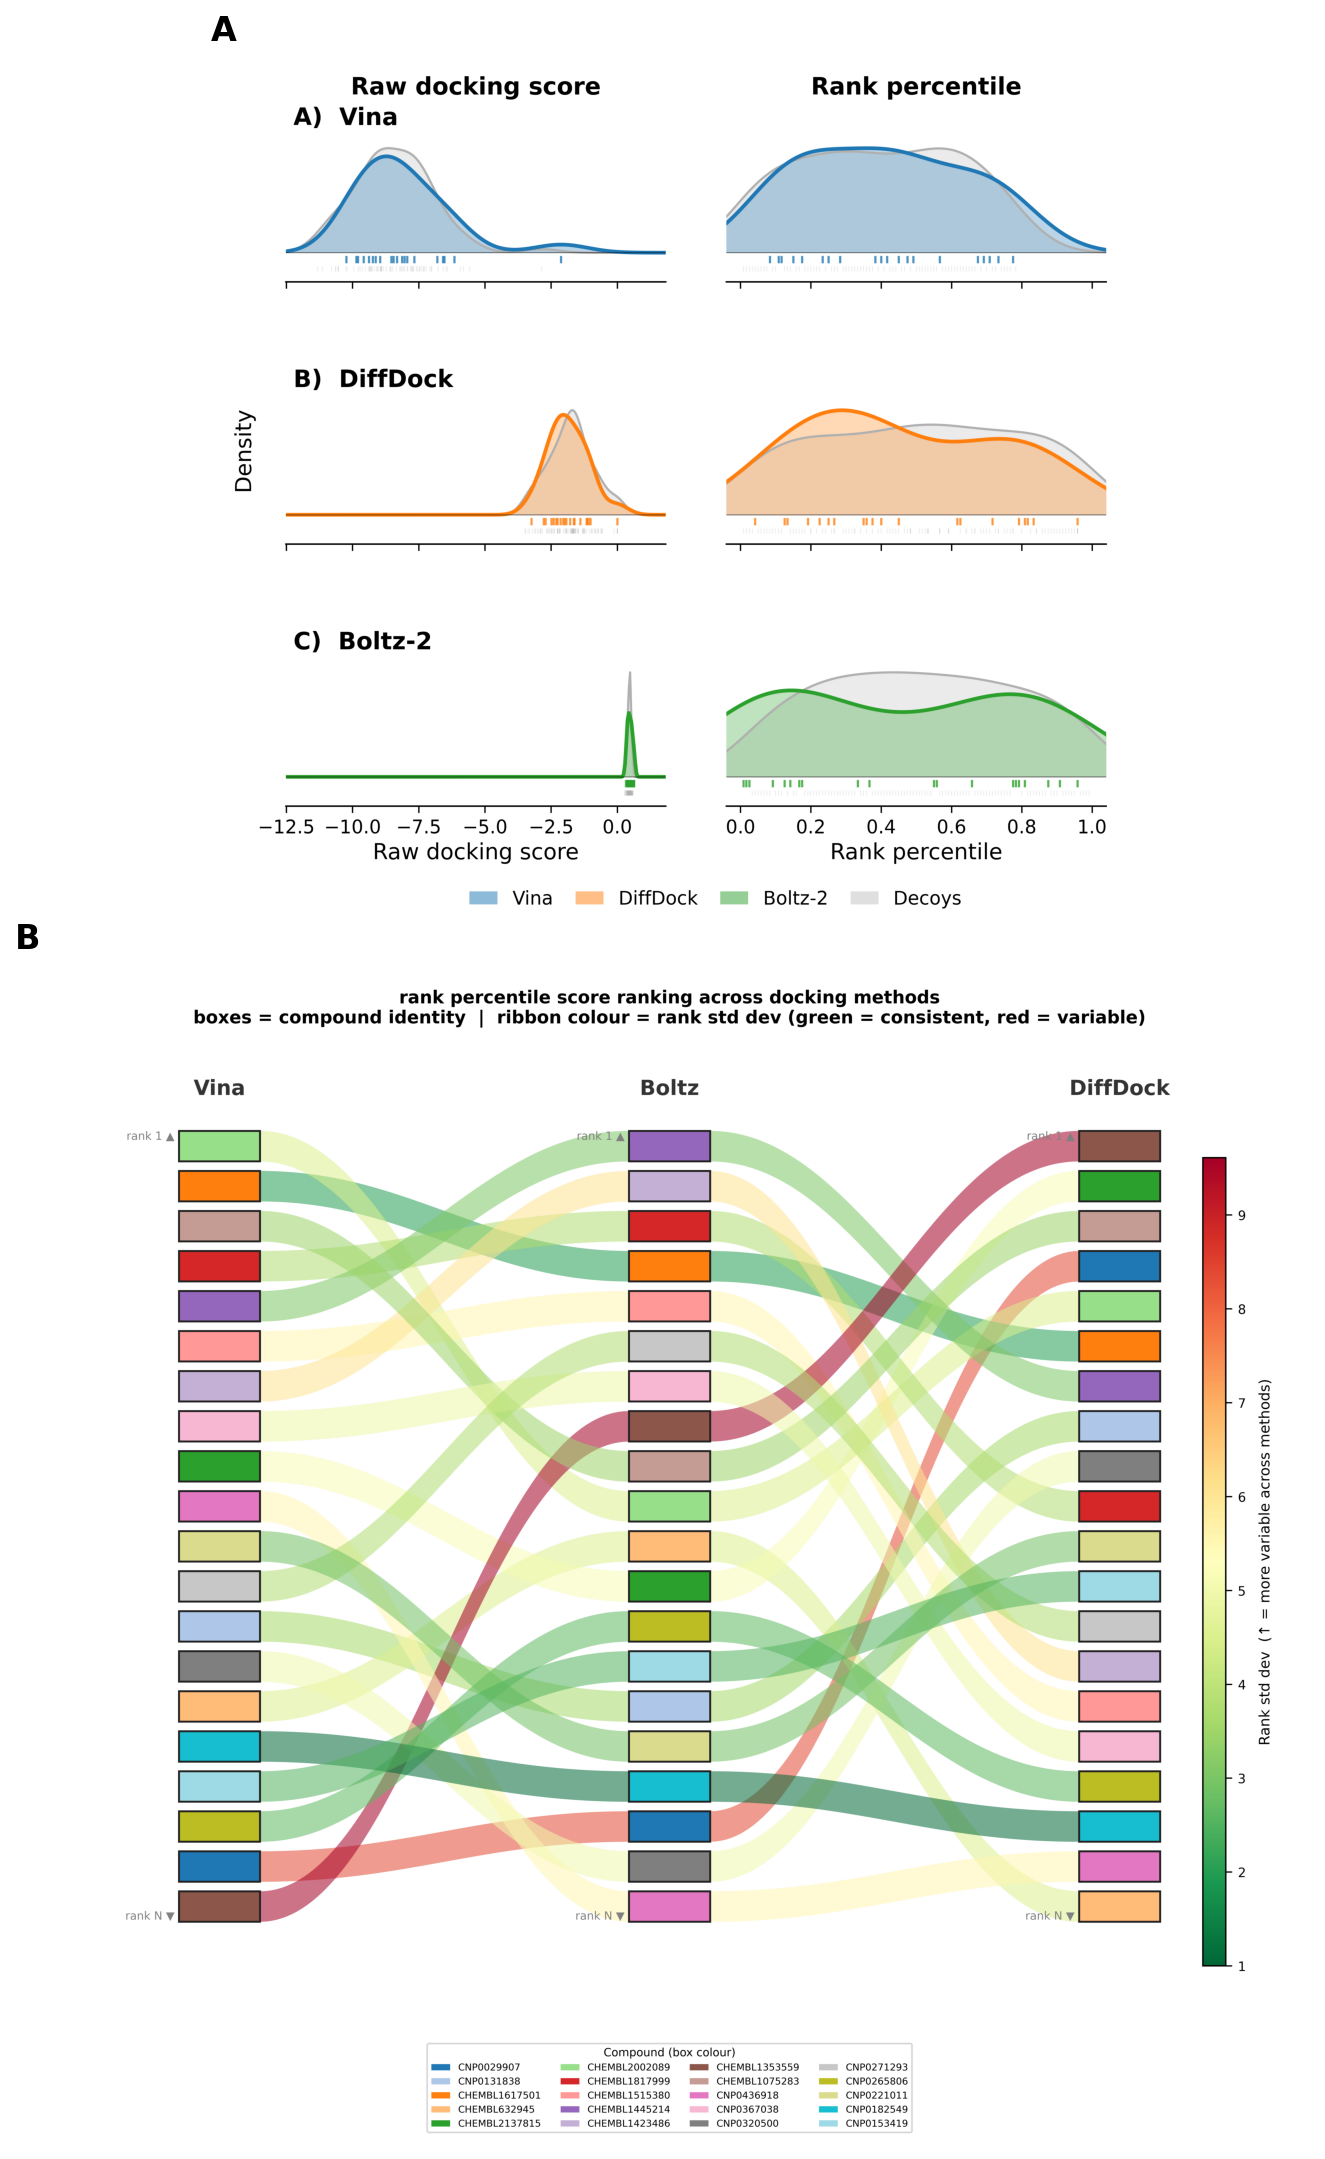

Saved panel v2 (rank-std ribbons): np_synthetic_comparison/guild_figures/guild_panel_v2.png


In [6]:
def make_panel(dist_path, sankey_path, out_path, panel_tag):
    """
    Composite: distributions on top (A), Sankey below (B).
    Both are loaded from saved PNGs so this cell is independent of figure state.
    """
    dist_img   = plt.imread(dist_path)
    sankey_img = plt.imread(sankey_path)

    # Height ratios derived from source figure sizes (distributions 8 in, Sankey 10 in)
    fig_p = plt.figure(figsize=(16, 18), constrained_layout=False)
    gs = fig_p.add_gridspec(2, 1, height_ratios=[1, 1.35], hspace=0.05)

    ax_dist   = fig_p.add_subplot(gs[0])
    ax_sankey = fig_p.add_subplot(gs[1])

    for ax_img, img in [(ax_dist, dist_img), (ax_sankey, sankey_img)]:
        ax_img.imshow(img)
        ax_img.set_axis_off()

    # Panel tags top-left
    for ax_img, tag in [(ax_dist, "A"), (ax_sankey, "B")]:
        ax_img.text(-0.01, 1.02, tag,
                    transform=ax_img.transAxes,
                    fontsize=16, fontweight="bold", va="bottom", ha="left")

    out_p = os.path.join(OUT_DIR, out_path)
    fig_p.savefig(out_p, dpi=600, bbox_inches="tight")
    plt.show()
    print(f"Saved panel {panel_tag}: {out_p}")


dist_png      = os.path.join(OUT_DIR, "figure_2_score_distributions.png")
sankey_v1_png = os.path.join(OUT_DIR, "guild_rank_alluvial_v1.png")
sankey_v2_png = os.path.join(OUT_DIR, "guild_rank_alluvial.png")

make_panel(dist_png, sankey_v1_png, "guild_panel_v1.png", "v1 (compound ribbons)")
make_panel(dist_png, sankey_v2_png, "guild_panel_v2.png", "v2 (rank-std ribbons)")